In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from sklearn.preprocessing import LabelEncoder


In [2]:
audio_df = pd.read_csv('./samlet2.csv', on_bad_lines='skip')
df = audio_df[audio_df['timestamp'] != 0].copy()

df['sample_c'] = df['samplevalue'].astype(np.int16) - 128
df['sample_float'] = df['sample_c'].astype(np.float32) / 128.0

files = df['file'].unique()
file_action_map = df.groupby('file')['action'].first()
actions = file_action_map.loc[files].values

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    stratify=actions,
    random_state=42
)

df_test = df[df['file'].isin(test_files)]
df_train = df[df['file'].isin(train_files)]


In [11]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

TARGET_LEN = 15800
DOWNSAMPLE_FACTOR = 2
L = TARGET_LEN // DOWNSAMPLE_FACTOR  # = 7900

print(f"L = {L}")  # Skal vise: L = 7900

def build_dataset(df_subset, label_encoder):
    X_list = []
    y_list = []

    for file_id, g in df_subset.groupby('file', sort=False):
        x = g['sample_float'].values
        x = x[:TARGET_LEN]
        x = x[::DOWNSAMPLE_FACTOR]  # Downsample
        
        y = g['action'].iloc[0]
        
        X_list.append(x)
        y_list.append(y)

    X = np.stack(X_list, axis=0)
    X = X[..., np.newaxis]
    
    y_enc = label_encoder.transform(y_list)
    
    print(f"Input shape: {X.shape}, Labels: {np.bincount(y_enc)}")
    
    return X, y_enc

# Byg datasæt
le = LabelEncoder().fit(df_train['action'])
X_train, y_train = build_dataset(df_train, le)
X_test, y_test = build_dataset(df_test, le)

# Label mapping til senere brug
label_mapping = {i: cls for i, cls in enumerate(le.classes_)}
print(f"Label mapping: {label_mapping}")

L = 7900
Input shape: (80, 7900, 1), Labels: [40 40]
Input shape: (20, 7900, 1), Labels: [10 10]
Label mapping: {0: 'knock', 1: 'noise'}


In [12]:
tf.keras.backend.clear_session()

def create_model(L):
    model = keras.Sequential([
        layers.Input(shape=(L, 1)),
        layers.SeparableConv1D(filters=10, kernel_size=9, padding='same',activation='relu'),
        layers.MaxPooling1D(2),
        layers.SeparableConv1D(10, 9, padding='same', activation='relu'),
#        layers.SeparableConv1D(12, 9, padding='same', activation='relu'),
        layers.MaxPooling1D(2),
        layers.SeparableConv1D(10, 7, padding='same', activation='relu'),
#        layers.SeparableConv1D(32, 7, padding='same', activation='relu'),
        layers.MaxPooling1D(2),
        layers.GlobalAveragePooling1D(),
        layers.Dense(24, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),         
        layers.Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=7e-4), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy'])
    
    return model

model = create_model(L)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 7900, 10)       │            29 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3950, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 3950, 10)       │           200 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1975, 10)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_2              │ (None, 1975, 10)       │           180 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 987, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723 (2.82 KB)

 Trainable params: 723 (2.82 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Test accuracy: 0.850
Macro F1: 0.847
Confusion matrix:
 [[ 7  3]
 [ 0 10]]

Klasserapport:
               precision    recall  f1-score   support

       knock      1.000     0.700     0.824        10
       noise      0.769     1.000     0.870        10

    accuracy                          0.850        20
   macro avg      0.885     0.850     0.847        20
weighted avg      0.885     0.850     0.847        20



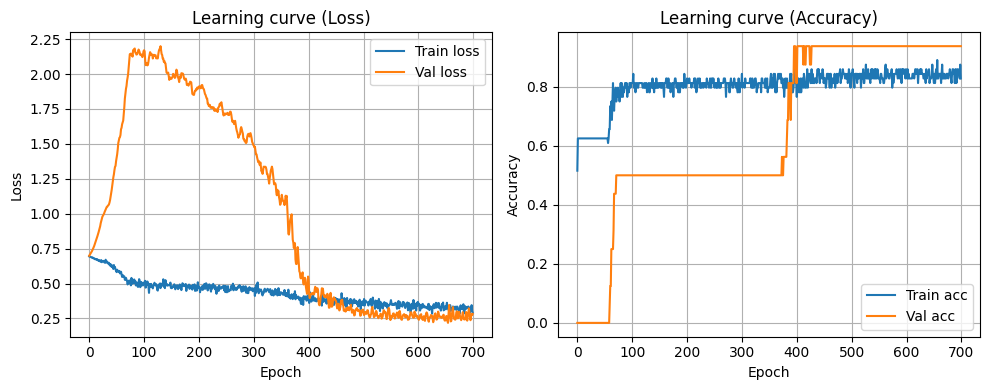

In [13]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # hold-out fra train
    epochs=700,
    batch_size=16,
    verbose=0
)

# Learning curves: tab (loss) og nøjagtighed (accuracy)
plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Learning curve (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.title('Learning curve (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show

# Test-evaluering
y_proba = model.predict(X_test)
y_pred = np.argmax(y_proba, axis=1)

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {acc:.3f}")
print(f"Macro F1: {f1m:.3f}")
print("Confusion matrix:\n", cm)

# (valgfrit) Detaljeret rapport med klassenavne
target_names = [label_mapping[i] for i in range(2)]
print("\nKlasserapport:\n", classification_report(y_test, y_pred, target_names=target_names, digits=3))

In [14]:
from glob import glob

def representative_dataset():
    files = sorted(glob("clips_downsampled/*.bin"))[:50]
    
    for f in files:
        x_raw = np.fromfile(f, dtype=np.uint8)[:L]  
        x = ((x_raw.astype(np.int16) - 128).astype(np.float32) / 128.0).reshape(1, L, 1)
        yield [x]

# Konverter til TFLite INT8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

# Gem
with open("model_7900.tflite", "wb") as f:
    f.write(tflite_int8)


INFO:tensorflow:Assets written to: C:\Users\soje\AppData\Local\Temp\tmpjb11zlgc\assets


INFO:tensorflow:Assets written to: C:\Users\soje\AppData\Local\Temp\tmpjb11zlgc\assets


Saved artifact at 'C:\Users\soje\AppData\Local\Temp\tmpjb11zlgc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7900, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  1495412538256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412536528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412538064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412539216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412536720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412536336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412537872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412537104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412536144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495412539024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1495392885

In [ ]:
import pathlib

in_path = pathlib.Path("model_7900.tflite")
out_path = pathlib.Path("model_7900.h")
var_name = "model_int8_tflite"

data = in_path.read_bytes()

with out_path.open("w") as f:
    f.write(f"// Auto-generated from {in_path.name}\n")
    f.write(f"const unsigned char {var_name}[] = {{\n  ")
    f.write(", ".join(f"0x{b:02x}" for b in data))
    f.write("\n};\n")
    f.write(f"const unsigned int {var_name}_len = {len(data)};\n")
